# UPSCALeDEV 2025 Building/PV Postprocessing and QC

This source notebook converts the original UCSD building net-meter and PV exports into separate, quality-controlled 15-minute passive-meter data products. It reconstructs gross building demand before the model subtracts PV exactly once. Building and PV do not participate in wholesale-market bidding, so no wholesale baseline or baseline-relative response is constructed.

Author: Yizhan Gu, UCSD CER

## Method

- Raw timestamps are interval-ending local times; processed timestamps are interval starts.
- The America/Los_Angeles timezone is used during QC so the spring DST jump is not mistaken for missing data.
- Short internal gaps are interpolated sensor-by-sensor and explicitly flagged. Negative meter noise is clipped to zero and flagged.
- The downloaded building channels are net meters that already include onsite PV. Gross building demand is reconstructed as `p_load = p_meter_net + p_PV_embedded`; the model then uses `p_GI = p_load + p_EV + p_BESS - p_PV_total`, so every PV channel is subtracted exactly once.
- Building load and PV generation remain exogenous, uncontrollable meter quantities.
- They enter only the retail meter balance and therefore affect TOU, non-coincident demand, and on-peak demand charges.
- They are excluded from DA/RT energy positions, ancillary-service capacity, and wholesale-market revenue.
- July 2025 is the formal sensitivity period used for coverage validation.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
BUILDING_RAW = ROOT / '2025Data/Bldg_data/Bldg_load.csv'
PV_RAW = ROOT / '2025Data/PV_data/CSV_2025-08-06-18-42-25.csv'
BUILDING_OUT = ROOT / '2025Data/Bldg_data/Bldg_load_2025_15min_QC.csv'
PV_OUT = ROOT / '2025Data/PV_data/PV_generation_2025_15min_QC.csv'
BUILDING_SUMMARY = ROOT / '2025Data/Bldg_data/Bldg_load_2025_QC_summary.csv'
PV_SUMMARY = ROOT / '2025Data/PV_data/PV_generation_2025_QC_summary.csv'
TIMEZONE = 'America/Los_Angeles'
INTERVAL = pd.Timedelta(minutes=15)
FORMAL_START = pd.Timestamp('2025-07-01 00:00:00')
FORMAL_END = pd.Timestamp('2025-07-31 23:45:00')
# All PV channels in the current 2025 export are embedded behind one of the
# ten downloaded building net meters. Keep this mapping explicit so a future
# non-embedded PV channel is not accidentally added back to gross load.
EMBEDDED_PV_COLUMNS = [
    'HOUSING_BLDG_2.PV_SYSTEM#Real Power Mean#kW',
    'HOUSING_BLDG_3.3HPV#Real Power Mean#kW',
    'HOUSING_BLDG_4.PV#Real Power Mean#kW',
    'PV.Osler_Parking_PV_P8900#Real Power Mean#kW',
    'WARREN.FAH_P2320#Real Power Mean#kW',
]
print('Project root:', ROOT)

Project root: /Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024


In [2]:
def read_and_qc_sensor_matrix(path, resource):
    raw = pd.read_csv(path, low_memory=False)
    if 'Timestamp' not in raw.columns:
        raise KeyError(f'{path} must contain Timestamp')
    raw_interval_end = pd.to_datetime(raw['Timestamp'], errors='raise')
    # Convert interval-ending stamps to interval starts before timezone
    # localization. For example, the spring-DST 02:00 end stamp represents
    # the valid 01:45 interval start.
    raw_time = raw_interval_end - INTERVAL
    local_time = pd.DatetimeIndex(raw_time).tz_localize(TIMEZONE, ambiguous='raise', nonexistent='raise')
    if local_time.duplicated().any():
        raise ValueError(f'Duplicate raw timestamps in {resource}')
    sensor_cols = [c for c in raw.columns if c != 'Timestamp']
    values = raw[sensor_cols].apply(pd.to_numeric, errors='coerce')
    values.index = local_time
    full_index = pd.date_range(local_time.min(), local_time.max(), freq='15min', tz=TIMEZONE)
    inserted = ~full_index.isin(local_time)
    values = values.reindex(full_index)
    missing_before = values.isna()
    # Interpolate each physical meter independently; never interpolate an
    # already aggregated total.
    values = values.interpolate(method='time', limit=8, limit_area='inside')
    if values.isna().any().any():
        bad = values.index[values.isna().any(axis=1)]
        raise ValueError(f'Unresolved {resource} gaps: {list(bad[:8])}')
    negative_before = values < 0
    values = values.clip(lower=0.0)
    interval_start = full_index.tz_localize(None)
    flags = pd.DataFrame({
        'qc_inserted_timestamp': inserted.astype(bool),
        'qc_imputed_sensor_value': missing_before.any(axis=1).to_numpy(bool),
        'qc_negative_sensor_clipped': negative_before.any(axis=1).to_numpy(bool),
    })
    flags['qc_any'] = flags.any(axis=1)
    summary = {
        'resource': resource,
        'raw_file': str(path.relative_to(ROOT)),
        'raw_rows': len(raw),
        'processed_rows': len(values),
        'raw_sensor_count': len(sensor_cols),
        'inserted_timestamp_rows': int(flags['qc_inserted_timestamp'].sum()),
        'imputed_sensor_rows': int(flags['qc_imputed_sensor_value'].sum()),
        'negative_clipped_rows': int(flags['qc_negative_sensor_clipped'].sum()),
        'processed_start': str(interval_start.min()),
        'processed_end': str(interval_start.max()),
    }
    values.index = interval_start
    return values, flags, summary

building_sensors, building_flags, building_summary = read_and_qc_sensor_matrix(BUILDING_RAW, 'building_net_meter')
pv_sensors, pv_flags, pv_summary = read_and_qc_sensor_matrix(PV_RAW, 'PV')
missing_embedded = sorted(set(EMBEDDED_PV_COLUMNS) - set(pv_sensors.columns))
if missing_embedded:
    raise KeyError(f'Embedded PV mapping is missing source columns: {missing_embedded}')
nonembedded_pv_columns = [c for c in pv_sensors.columns if c not in EMBEDDED_PV_COLUMNS]
p_meter_net = building_sensors.sum(axis=1)
p_pv_embedded = pv_sensors[EMBEDDED_PV_COLUMNS].sum(axis=1)
p_pv_nonembedded = pv_sensors[nonembedded_pv_columns].sum(axis=1) if nonembedded_pv_columns else pd.Series(0.0, index=pv_sensors.index)
p_pv_total = p_pv_embedded + p_pv_nonembedded
p_load_gross = p_meter_net + p_pv_embedded
building = pd.DataFrame({
    'Interval start': p_meter_net.index,
    'p_meter_net_kW': p_meter_net.to_numpy(float),
    'p_PV_embedded_kW': p_pv_embedded.to_numpy(float),
    'p_load_kW': p_load_gross.to_numpy(float),
})
pv = pd.DataFrame({
    'Interval start': p_pv_total.index,
    'p_PV_kW': p_pv_total.to_numpy(float),
    'p_PV_embedded_kW': p_pv_embedded.to_numpy(float),
    'p_PV_nonembedded_kW': p_pv_nonembedded.to_numpy(float),
})
for column in building_flags:
    building[column] = building_flags[column].to_numpy(bool)
for column in pv_flags:
    pv[column] = pv_flags[column].to_numpy(bool)
accounting_residual = (building['p_load_kW'] - pv['p_PV_kW']) - (building['p_meter_net_kW'] - pv['p_PV_nonembedded_kW'])
ACCOUNTING_IDENTITY_MAX_ERROR_KW = float(accounting_residual.abs().max())
if ACCOUNTING_IDENTITY_MAX_ERROR_KW > 1e-9:
    raise ValueError(f'PV single-subtraction identity failed: {ACCOUNTING_IDENTITY_MAX_ERROR_KW:.3e} kW')
building_summary.update({
    'meter_semantics': 'downloaded channels are net of onsite PV',
    'embedded_pv_sensor_count': len(EMBEDDED_PV_COLUMNS),
    'nonembedded_pv_sensor_count': len(nonembedded_pv_columns),
    'meter_balance_identity_max_error_kW': ACCOUNTING_IDENTITY_MAX_ERROR_KW,
    'minimum_kW': float(building['p_load_kW'].min()),
    'maximum_kW': float(building['p_load_kW'].max()),
})
pv_summary.update({
    'embedded_pv_sensor_count': len(EMBEDDED_PV_COLUMNS),
    'nonembedded_pv_sensor_count': len(nonembedded_pv_columns),
    'minimum_kW': float(pv['p_PV_kW'].min()),
    'maximum_kW': float(pv['p_PV_kW'].max()),
})

In [3]:
BUILDING_OUT.parent.mkdir(parents=True, exist_ok=True)
PV_OUT.parent.mkdir(parents=True, exist_ok=True)
building.to_csv(BUILDING_OUT, index=False, float_format='%.6f')
pv.to_csv(PV_OUT, index=False, float_format='%.6f')

def final_summary(frame, summary, value_col):
    formal = frame[frame['Interval start'].between(FORMAL_START, FORMAL_END)].copy()
    summary = dict(summary)
    summary.update({
        'market_role': 'passive retail-meter quantity; excluded from all wholesale positions',
        'formal_period_start': str(FORMAL_START),
        'formal_period_end': str(FORMAL_END),
        'formal_rows': len(formal),
        'formal_missing_values': int(formal[[value_col]].isna().sum().sum()),
        'formal_mean_actual_kW': float(formal[value_col].mean()),
    })
    return pd.DataFrame([summary])

building_summary_df = final_summary(building, building_summary, 'p_load_kW')
pv_summary_df = final_summary(pv, pv_summary, 'p_PV_kW')
building_summary_df.to_csv(BUILDING_SUMMARY, index=False)
pv_summary_df.to_csv(PV_SUMMARY, index=False)
display(building_summary_df)
display(pv_summary_df)

,resource,raw_file,raw_rows,processed_rows,raw_sensor_count,inserted_timestamp_rows,imputed_sensor_rows,negative_clipped_rows,processed_start,processed_end,...,nonembedded_pv_sensor_count,meter_balance_identity_max_error_kW,minimum_kW,maximum_kW,market_role,formal_period_start,formal_period_end,formal_rows,formal_missing_values,formal_mean_actual_kW
0,building_net_meter,2025Data/Bldg_data/Bldg_load.csv,20342,20348,10,6,12,14,2025-01-01 00:00:00,2025-07-31 23:45:00,...,0,2.273737e-13,846.996116,2235.457891,passive retail-meter quantity; excluded from a...,2025-07-01 00:00:00,2025-07-31 23:45:00,2976,0,1255.114778


,resource,raw_file,raw_rows,processed_rows,raw_sensor_count,inserted_timestamp_rows,imputed_sensor_rows,negative_clipped_rows,processed_start,processed_end,embedded_pv_sensor_count,nonembedded_pv_sensor_count,minimum_kW,maximum_kW,market_role,formal_period_start,formal_period_end,formal_rows,formal_missing_values,formal_mean_actual_kW
0,PV,2025Data/PV_data/CSV_2025-08-06-18-42-25.csv,20340,20348,5,8,10,10109,2025-01-01 00:00:00,2025-07-31 23:45:00,5,0,0.0,539.076092,passive retail-meter quantity; excluded from a...,2025-07-01 00:00:00,2025-07-31 23:45:00,2976,0,128.842389


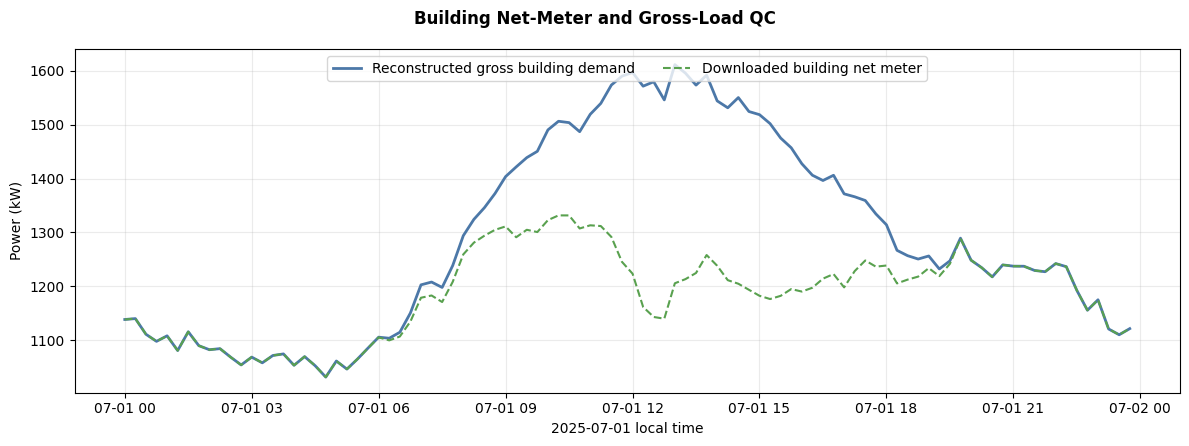

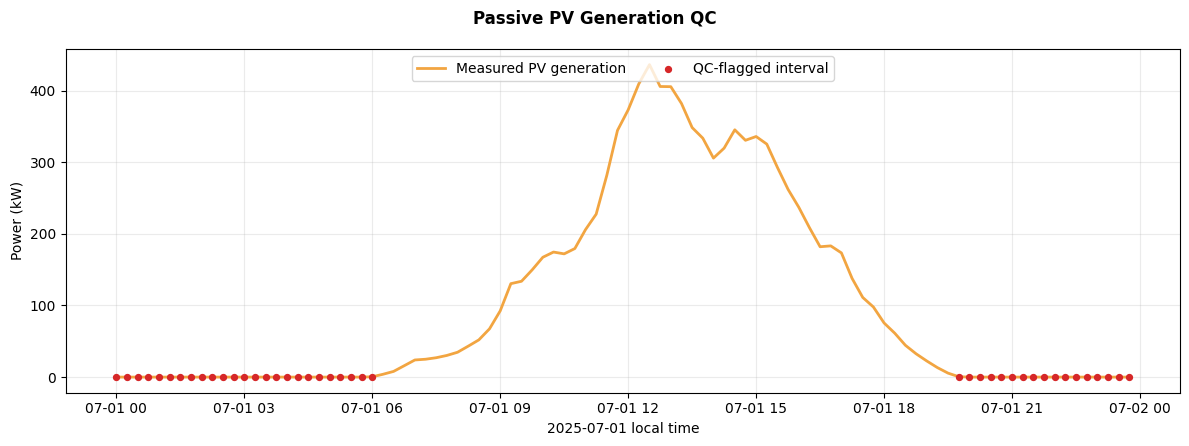

In [4]:
def save_qc_plot(frame, value_col, title, output, color, label):
    day = frame[frame['Interval start'].between('2025-07-01 00:00:00', '2025-07-01 23:45:00')].copy()
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(day['Interval start'], day[value_col], color=color, label=label, linewidth=2)
    if value_col == 'p_load_kW':
        ax.plot(day['Interval start'], day['p_meter_net_kW'], color='#59a14f', ls='--', lw=1.5, label='Downloaded building net meter')
    flagged = day['qc_any'].astype(bool)
    if flagged.any():
        ax.scatter(day.loc[flagged, 'Interval start'], day.loc[flagged, value_col], color='#d62728', s=18, label='QC-flagged interval', zorder=3)
    ax.set_ylabel('Power (kW)')
    ax.set_xlabel('2025-07-01 local time')
    ax.legend(loc='upper center', ncol=3)
    ax.grid(alpha=0.25)
    fig.suptitle(title, fontweight='bold')
    fig.tight_layout()
    fig.savefig(output, dpi=300, bbox_inches='tight')
    plt.show()

save_qc_plot(building, 'p_load_kW', 'Building Net-Meter and Gross-Load QC',
             BUILDING_OUT.parent / 'Bldg_load_2025_QC_20250701.png', '#4c78a8', 'Reconstructed gross building demand')
save_qc_plot(pv, 'p_PV_kW', 'Passive PV Generation QC',
             PV_OUT.parent / 'PV_generation_2025_QC_20250701.png', '#f2a541', 'Measured PV generation')

In [5]:
def validate_formal_period(frame, value_col):
    formal = frame[frame['Interval start'].between(FORMAL_START, FORMAL_END)].copy()
    expected = pd.date_range(FORMAL_START, FORMAL_END, freq='15min')
    assert formal['Interval start'].reset_index(drop=True).equals(pd.Series(expected, name='Interval start'))
    assert not formal[[value_col]].isna().any().any()
    assert (formal[value_col] >= 0).all()
    assert not formal['Interval start'].duplicated().any()
    return {'rows': len(formal), 'missing_values': 0, 'minimum_kW': float(formal[value_col].min()), 'maximum_kW': float(formal[value_col].max())}

validation = {
    'building': validate_formal_period(building, 'p_load_kW'),
    'PV': validate_formal_period(pv, 'p_PV_kW'),
}
assert set(pv_sensors.columns) == set(EMBEDDED_PV_COLUMNS), 'Current aggregate export contains an unmapped PV channel'
assert ACCOUNTING_IDENTITY_MAX_ERROR_KW <= 1e-9
validation['accounting'] = {
    'building_meter_semantics': 'net of embedded PV',
    'embedded_PV_channels': len(EMBEDDED_PV_COLUMNS),
    'nonembedded_PV_channels': len(nonembedded_pv_columns),
    'single_subtraction_identity_max_error_kW': ACCOUNTING_IDENTITY_MAX_ERROR_KW,
}
print(validation)
print('BTM postprocessing validation: PASS')

{'building': {'rows': 2976, 'missing_values': 0, 'minimum_kW': 993.5996588030827, 'maximum_kW': 1728.562753677369}, 'PV': {'rows': 2976, 'missing_values': 0, 'minimum_kW': 0.0, 'maximum_kW': 519.9668922424315}, 'accounting': {'building_meter_semantics': 'net of embedded PV', 'embedded_PV_channels': 5, 'nonembedded_PV_channels': 0, 'single_subtraction_identity_max_error_kW': 2.2737367544323206e-13}}
BTM postprocessing validation: PASS
